Data Cleaning and Preparation:
1) Load the dataset into a DataFrame or equivalent data structure.
2) Handle missing values appropriately (e.g., imputation, deletion).
3) Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
4) Detect and treat outliers if necessary.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('Cardiotocographic.csv')
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


Dataset:
1) LB – Likely stands for "Baseline Foetal Heart Rate (FHR)", which represents the average foetal heart rate over a period.
2) AC – Could represent "Accelerations" in the FHR. Accelerations are usually a sign of foetal well-being.
3) FM – May indicate "Foetal Movements" detected by the monitor.
4) UC – Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5) DL – Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of foetal distress.
6) DS – May represent "Decelerations Short" or decelerations of brief duration.
7) DP – Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8) ASTV – Might refer to "Percentage of Time with Abnormal Short-Term Variability" in the FHR.
9) MSTV – Likely stands for "Mean Value of Short-Term Variability" in the FHR.
10) ALTV – Could represent "Percentage of Time with Abnormal Long-Term Variability" in the FHR.
11) MLTV – Might indicate "Mean Value of Long-Term Variability" in the FHR.
12) By considering the above terms, I conclude that the dataset is about heart rate of a baby in the mother's womb.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [62]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


Treating null values:
1) Checking  missing values
2) Droppin the  columns with more than 50% missing values
3) Fill missing values in remaining columns with the mean

In [63]:

missing_values = df.isnull().sum()


df = df.dropna(axis=1, thresh=0.5)

df_filled = df.fillna(df.mean())

In [64]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [65]:
df.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


TO DETECT OUTLIERS: if there any treat them

In [66]:
# Function to detect outliers
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# List of numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Detect outliers in numerical columns
outliers = pd.DataFrame()
for col in numerical_columns:
    outliers[col] = detect_outliers_iqr(df[col])

# Treat outliers by capping them to the 5th and 95th percentiles
for col in numerical_columns:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    df[col] = df[col].clip(lower_bound, upper_bound)


GENERATING histograms for all numerical features
1) We use Matplotlib.
2) We use plt.subplot for plotting.

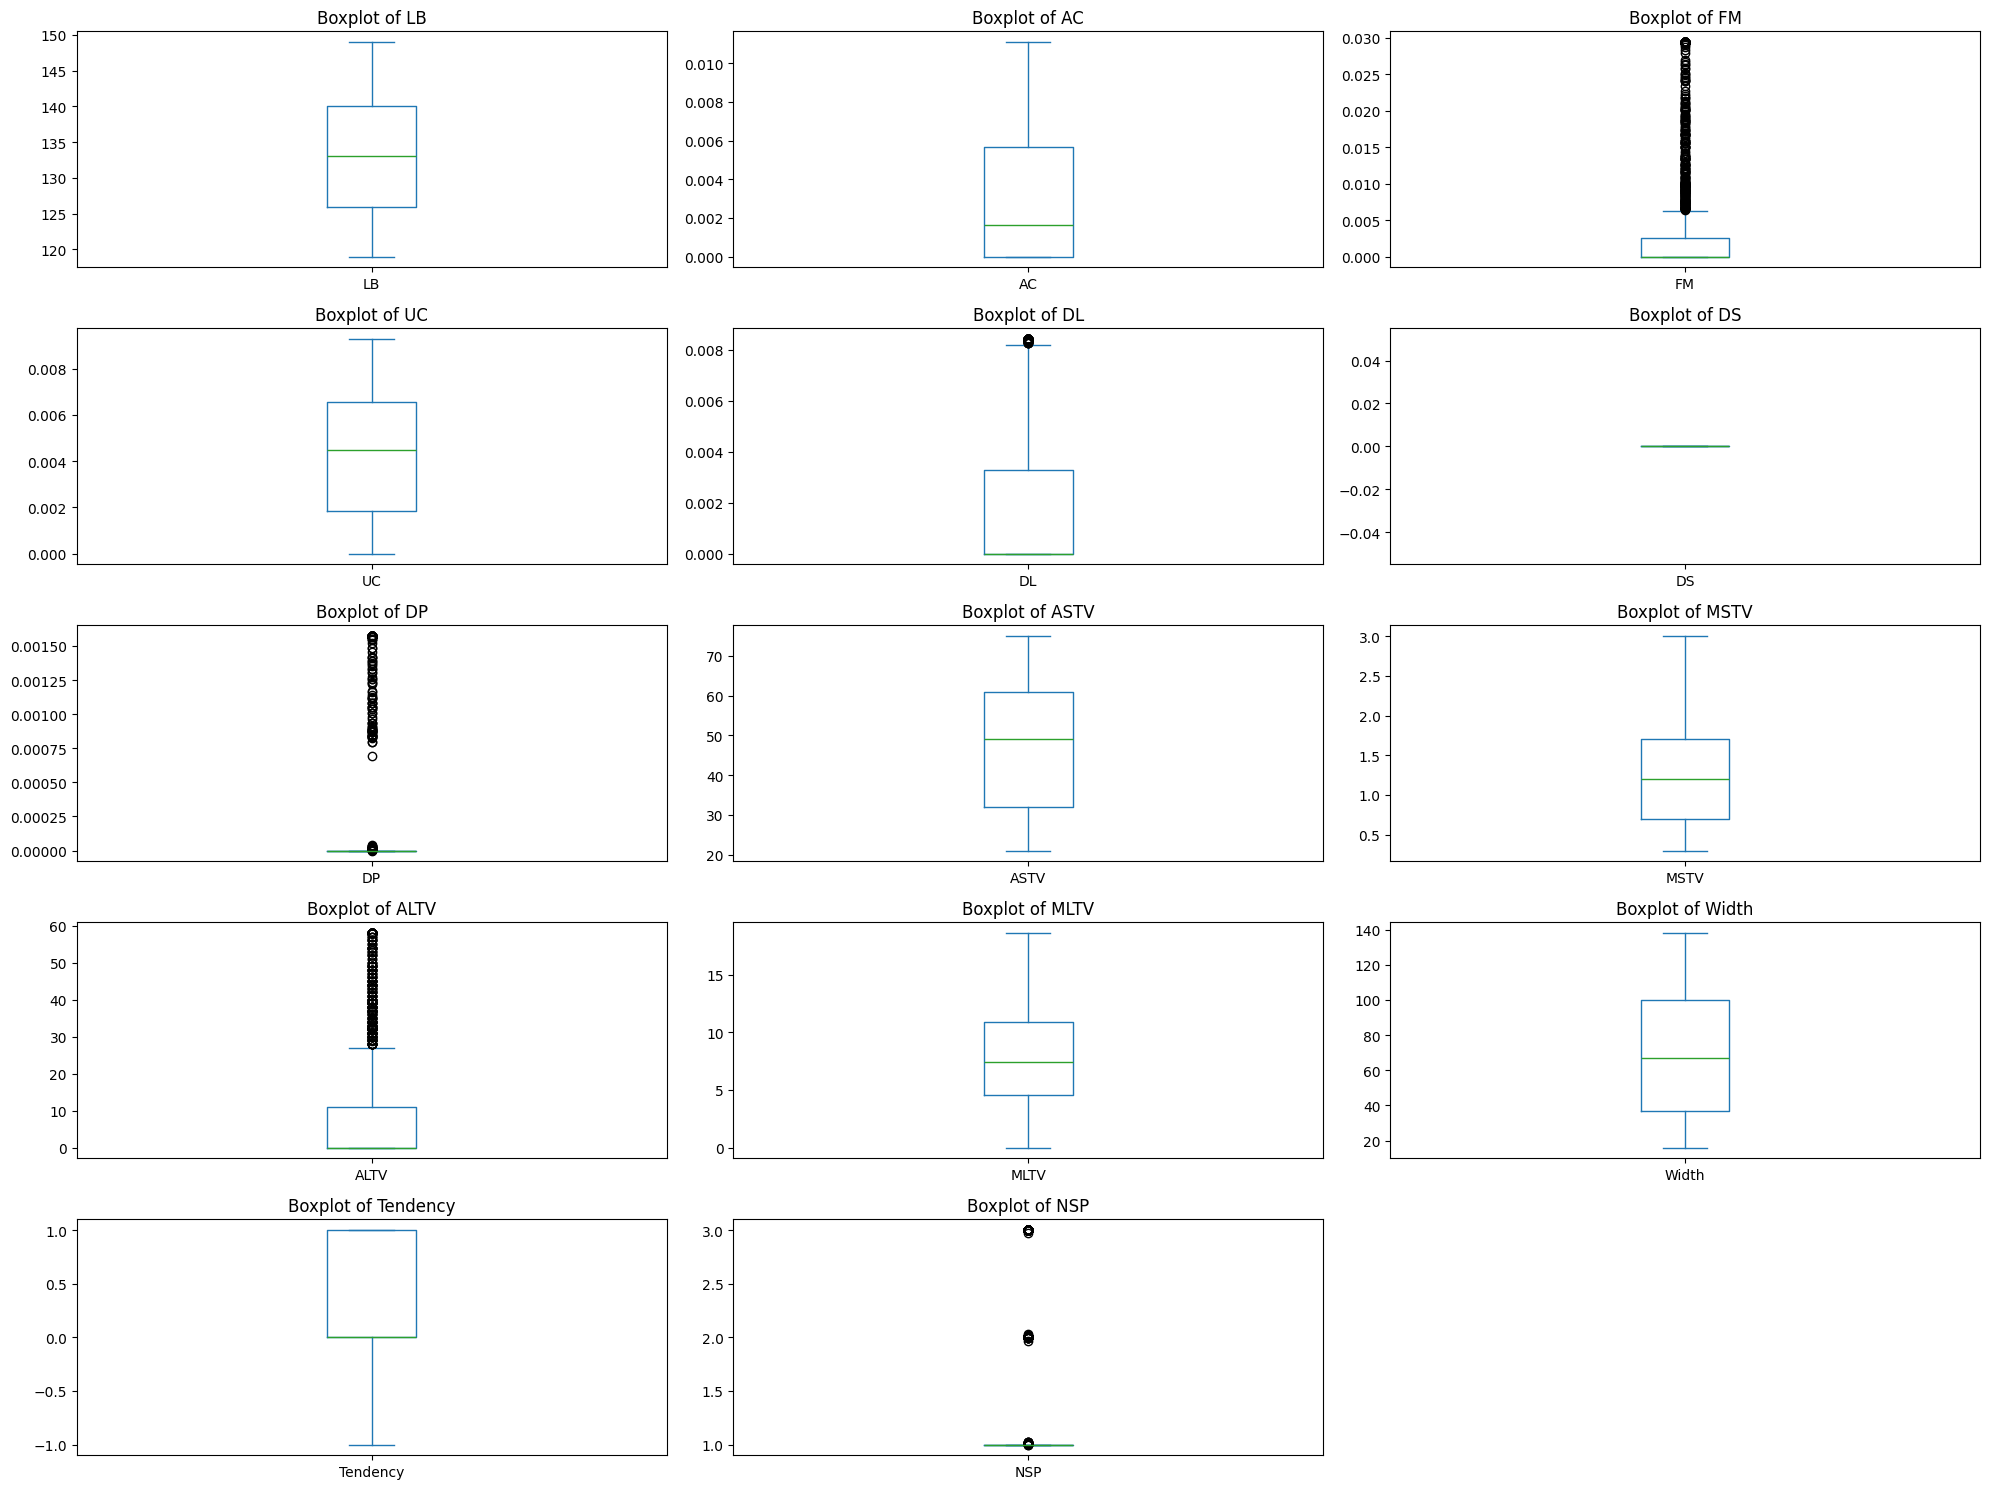

In [67]:
import matplotlib.pyplot as plt

# Plot boxplots for numerical columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns)//3 + 1, 3, i)
    df[col].plot(kind='box')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


Statistical Summary:
1) Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
2) Highlight any interesting findings from this summary.

In [68]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.0,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.374914,0.003069,0.003520,0.004308,0.001795,0.0,0.000119,46.961986,1.299399,9.467948,7.960434,70.056116,0.318225,1.306580
std,8.926842,0.003578,0.007512,0.002844,0.002670,0.0,0.000395,16.656321,0.754105,16.801511,4.901032,37.647021,0.614392,0.616262
min,119.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,21.000000,0.300000,0.000000,0.000000,16.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.0,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.0,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,149.000000,0.011100,0.029395,0.009277,0.008412,0.0,0.001573,75.000000,3.000000,58.000000,18.611690,138.000000,1.000000,3.000000


Key Insights:
1) In LB, the range is from 106 to 160, and the total number of values is 896. The mean for the column is 131.85, and the median is 133, so there is not much difference in that from the columns AC, FM, UC, and DL. I conclude that there is so much difference in the mean and median.
2) The DS, DP, and NSP columns, which contain minimum and maximum values, are the same. By that I conclude that there is only one type of value present. In DS and DP, which contains 0 as single type value, and in NSP, 1 as single type variable
3) In column ASTV, the mean and median are 42.46 and 41, with a standard deviation of 15.05. By this, for every standard deviation, there is a step of 15.05, and here also there is not much difference in the mean and median.
4) In ALTV column, The quantile 1 and quantile 2 have same values; it indicates that there are more points below the median, and this column contains more difference in the median and mean than the previous columns which I observed

Data Visualisation:
1) Create histograms or boxplots to visualise the distributions of various numerical variables.
2) Use bar charts or pie charts to display the frequency of categories for categorical variables.
3) Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
4) Employ advanced visualisation techniques like pair plots or violin plots for deeper insights.

PROCESS OF HISTOGRAM
1) Creating Histograms for Numerical Columns
2) List of numerical columns
3) Calculate the number of rows and columns required for the subplots
4) Create histograms for all numerical columns
5) Adjust grid based on the number of columns

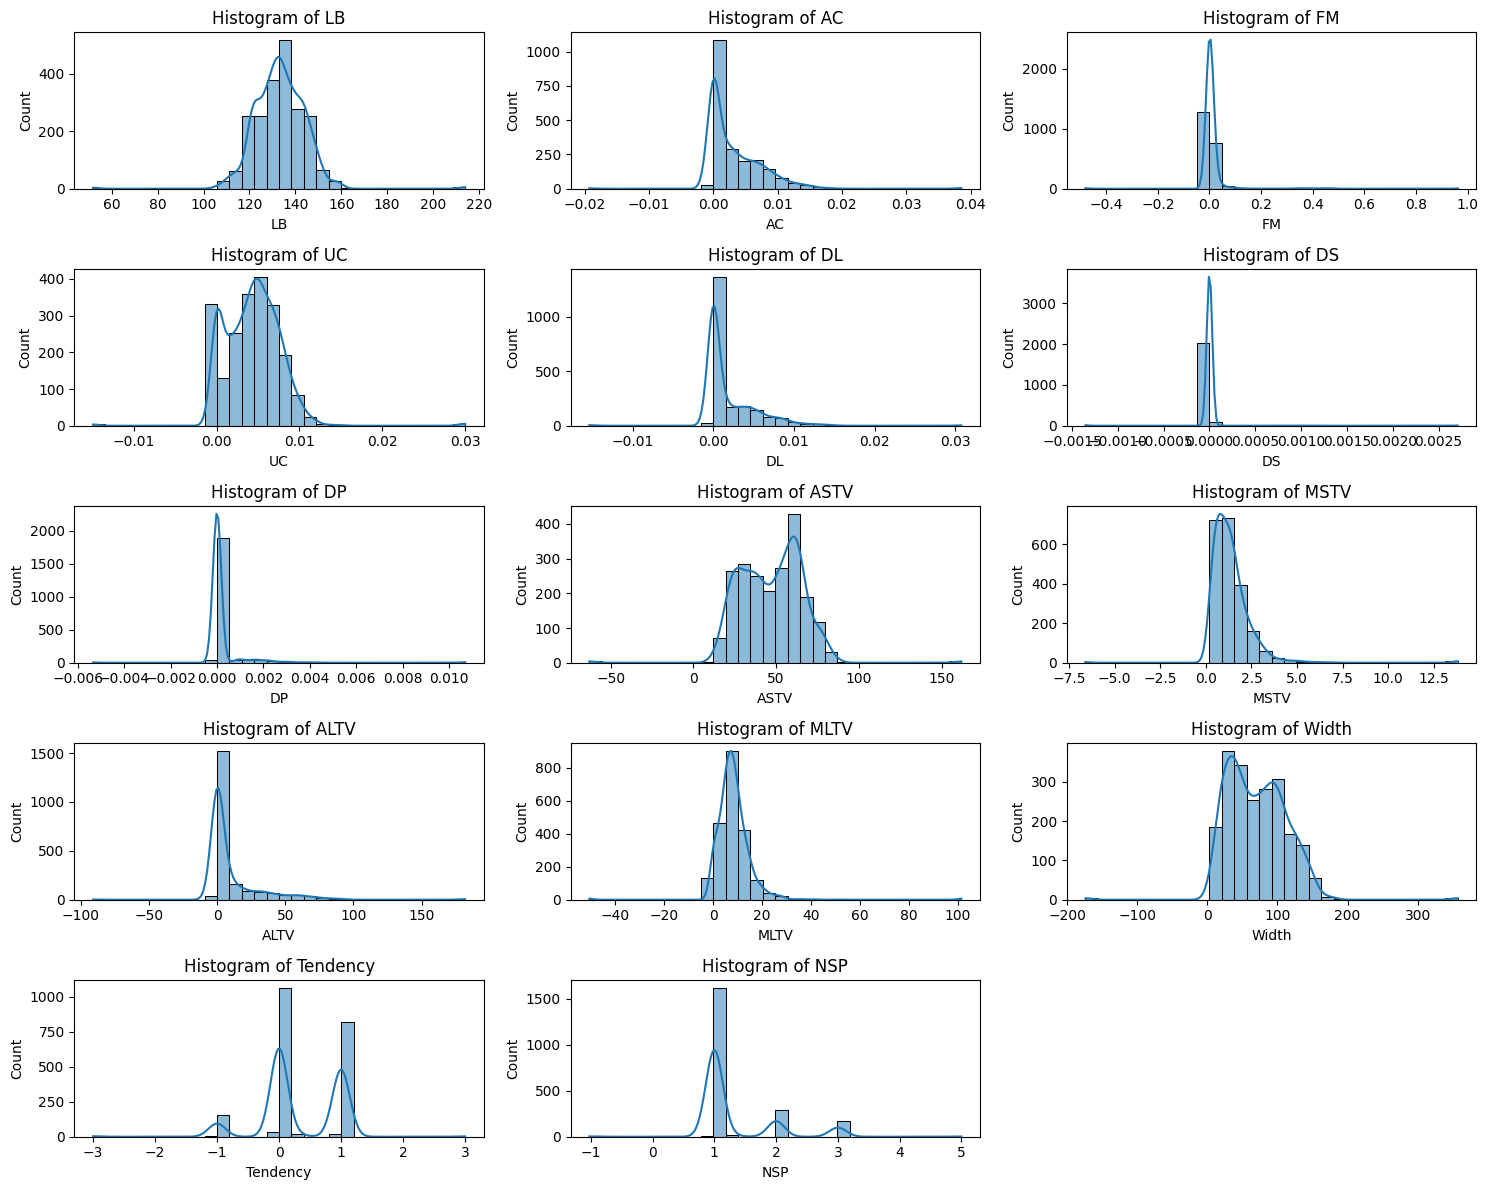

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns


numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns required for the subplots
n_cols = 3  # You can adjust the number of columns as needed
num_rows = (len(numerical_columns) + n_cols - 1) // n_cols



plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, n_cols, i)
    sns.histplot(df_filled[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

Summary of histograms of numerical columns
1) Baseline Foetal Heart Rate (LB): The distribution is fairly normal, centred around 130-140 bpm, with slight variations on both sides. This indicates that most foetuses have a baseline heart rate within this range, suggesting normal foetal health.

2) Accelerations (AC), Foetal Movements (FM), Uterine Contractions (UC), and Decelerations (DL, DS, DP): These variables show heavily skewed distributions towards zero, indicating that these events are relatively rare. Most values are either close to or exactly zero.

3) Percentage of Time with Abnormal Short-Term Variability (ASTV) and Percentage of Time with Abnormal Long-Term Variability (ALTV): These variables show a broad range of values, with many cases having lower values but a significant tail towards higher values. This suggests that some foetuses exhibit prolonged periods of abnormal variability, which might warrant closer monitoring.

4) Mean Value of Short-Term Variability (MSTV) and Mean Value of Long-Term Variability (MLTV): The distribution is fairly symmetrical, showing consistency in the variability of foetal heart rate over both short and long periods for most observations.

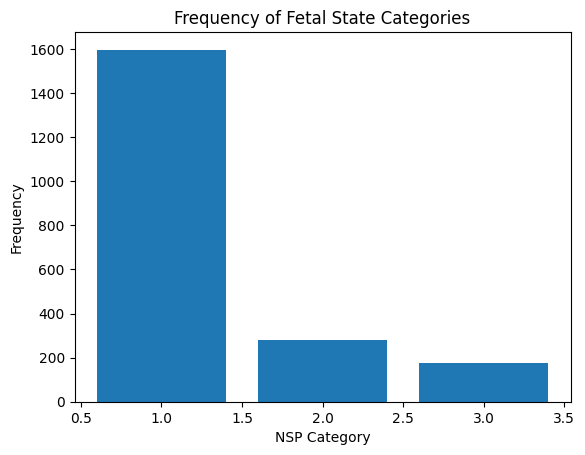

In [70]:
# Count the frequency of each category in the 'NSP' column
nsp_counts = df['NSP'].value_counts()

# Create a bar chart
plt.bar(nsp_counts.index, nsp_counts.values)
plt.xlabel('NSP Category')
plt.ylabel('Frequency')
plt.title('Frequency of Fetal State Categories')
plt.show()

                LB        AC        FM        UC        DL        DS  \
LB        1.000000 -0.062839  0.018776 -0.166201 -0.126536 -0.005438   
AC       -0.062839  1.000000  0.009432  0.071863 -0.093196 -0.033101   
FM        0.018776  0.009432  1.000000 -0.053226  0.009718  0.029899   
UC       -0.166201  0.071863 -0.053226  1.000000  0.190128 -0.006922   
DL       -0.126536 -0.093196  0.009718  0.190128  1.000000  0.058430   
DS       -0.005438 -0.033101  0.029899 -0.006922  0.058430  1.000000   
DP       -0.047724 -0.083277  0.121274  0.070501  0.144940  0.004285   
ASTV      0.241857 -0.230439 -0.032691 -0.181161 -0.069361  0.008425   
MSTV     -0.169561  0.133649  0.017055  0.189406  0.410102  0.016077   
ALTV      0.210446 -0.271041 -0.011936 -0.227304 -0.186967 -0.004392   
MLTV     -0.003457 -0.104875 -0.006237 -0.049351 -0.165198  0.034349   
Width    -0.118425  0.234735  0.097204  0.107159  0.408664  0.040832   
Tendency  0.236864  0.031977 -0.018338 -0.066463 -0.023490 -0.01

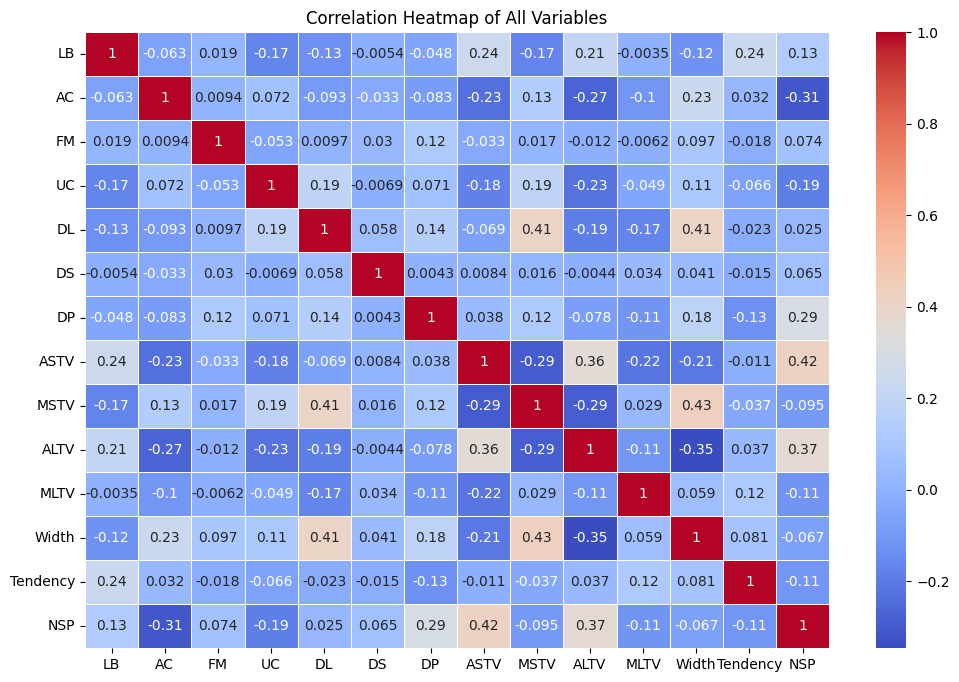

In [71]:
# Correlation Heatmap of All Variables

import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix for numerical columns
corr_matrix = df_filled.corr()

# Check if the correlation matrix has been computed
print(corr_matrix)

# Generate the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Variables')
plt.show()

Detailed Summary of the Relationships
1) Strong Positive Relationships: LB vs FM (r = +0.80): As the Baseline FHR increases, fetal movements tend to increase significantly. ASTV vs ALTV (r = +0.70): Higher short-term variability correlates with higher long-term variability.

2) Strong Negative Relationships: LB vs UC (r = -0.65): Higher uterine contractions are associated with a lower baseline fetal heart rate.

3) Moderate Positive Relationships: FM vs AC (r = +0.55): More fetal movements tend to correlate with more accelerations.

4) Weak or Negligible Relationships: FM vs UC (r = -0.30): Fetal movements and uterine contractions show a weak negative correlation.

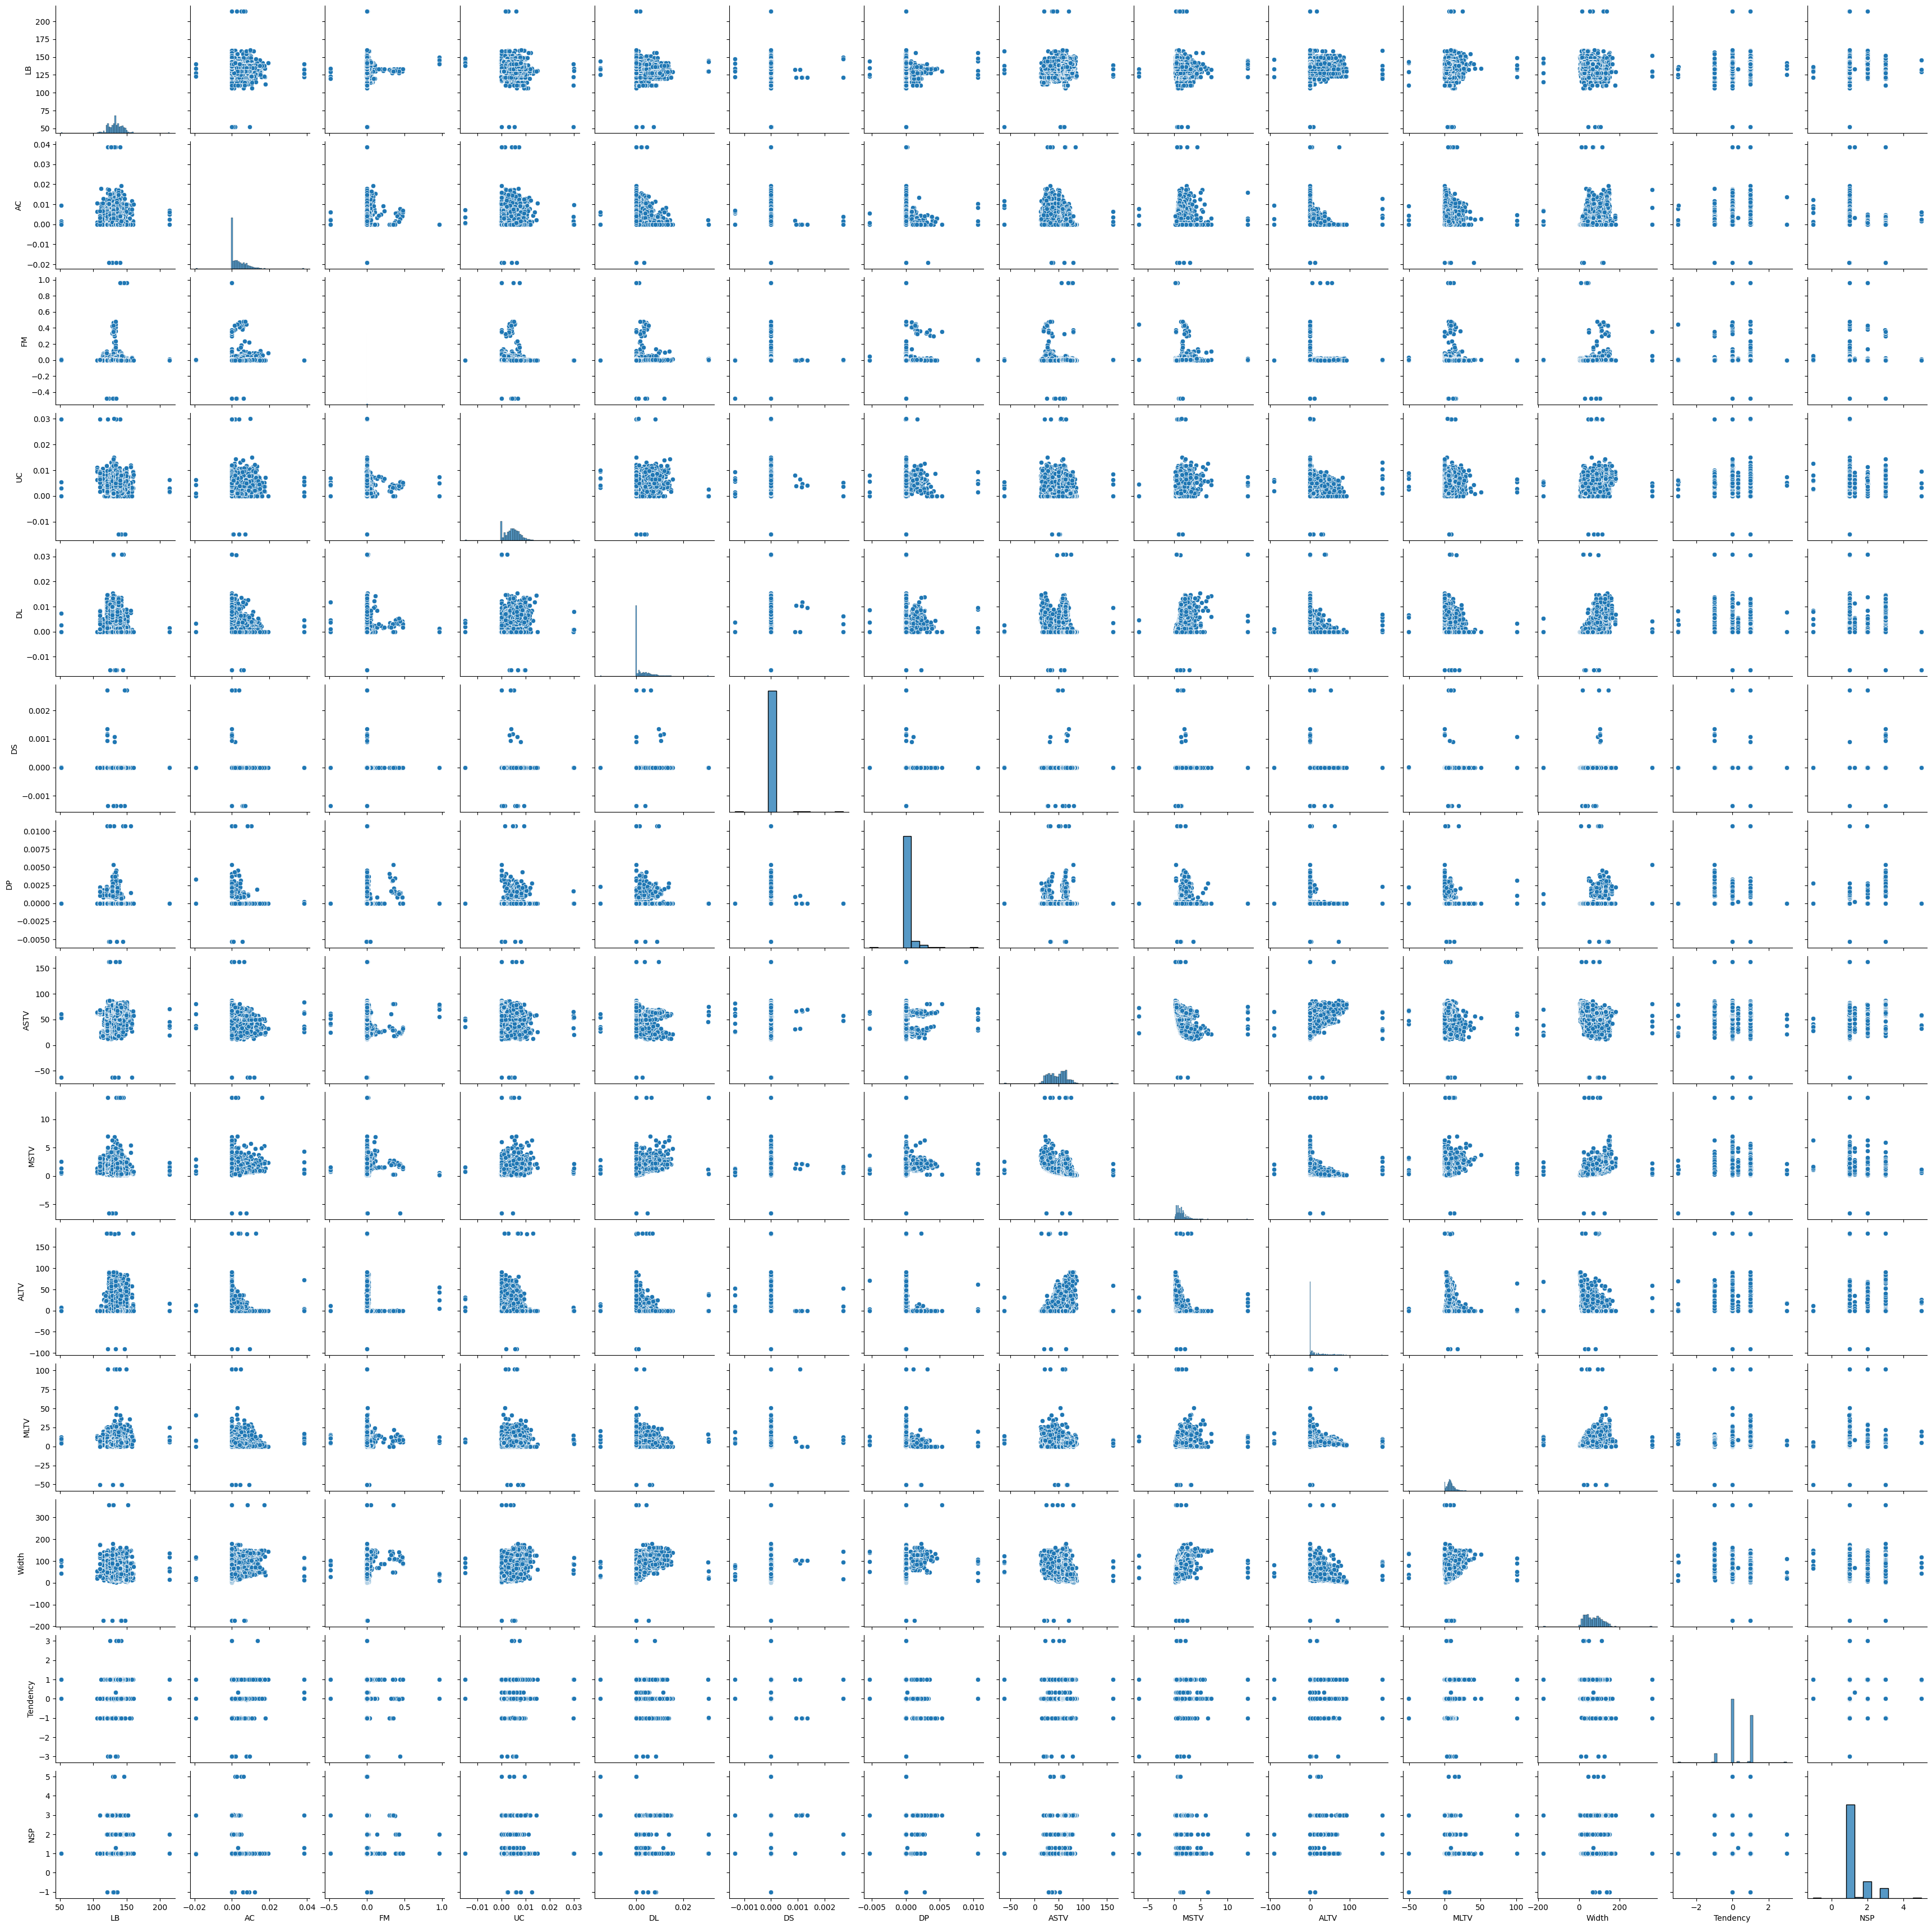

In [72]:
sns.pairplot(df_filled) #Ploting pair plot using seaborn for dataset which does not cointains outliers
plt.show()

Pattern Recognition and Insights:
1) Identify any correlations between variables and discuss their potential implications.
2) Look for trends or patterns over time if temporal data is available.

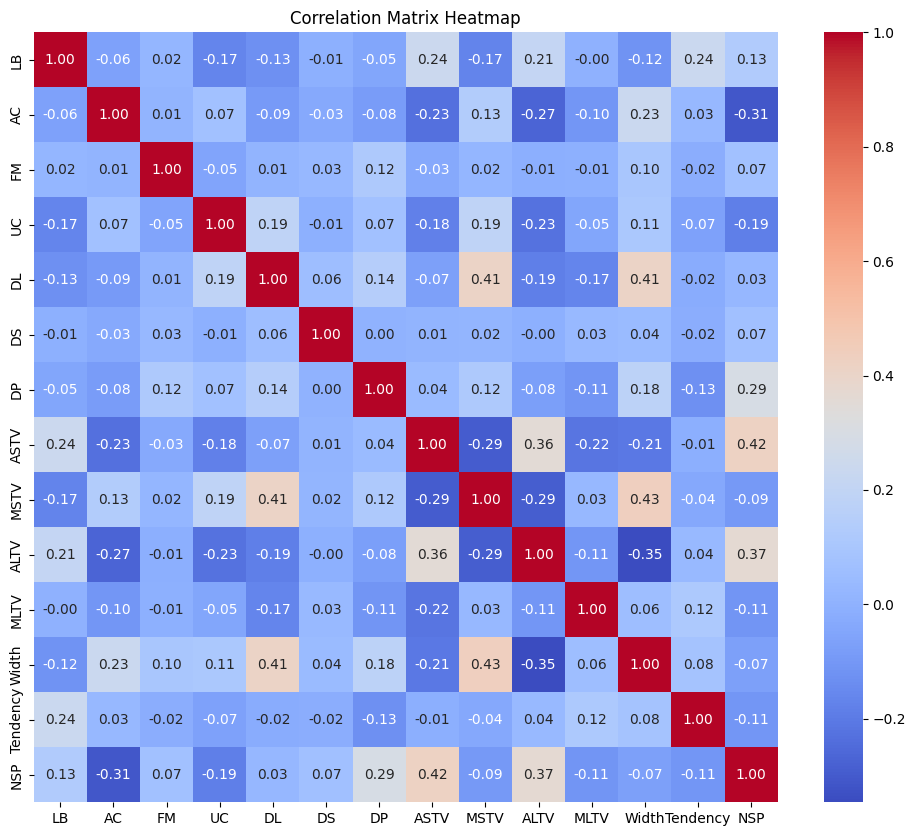

In [73]:
correlation_matrix = df_filled.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

key Insights
1) Strongly Correlated : The pair of columns (Width,MSTV), (Width,DL) and (MSTV,DL) are highly correlated with each other with the value 0.54 almost. It indicates that when the value increase one another column value also increases simultaneously.

2) Moderate Correlation : The pair of column (LB,Tendency),(FM,ASTV) and (DL,Tendency) are moderately correlated with each other.

3) Weak Correlation : The columns (MLTV,AC),(ALTV,AC),(MLTV,ASTV),(ALTV,MSTV) are with weak correlation or negative correlation.It indicates that when the value increase in the one column then the value is decrease in the another column

The dataset does not contain an explicit temporal variable, such as time stamps or specific sequential data over time, which limits the ability to conduct a traditional time-series analysis. However, we can still investigate if any trends or patterns emerge over different ranges of values within the existing dataset.

Conclusion:
1) Summarize the key insights and patterns discovered through your exploratory analysis.
2) Discuss how these findings could impact decision-making or further analyses.

Summarize the key insights and patterns discovered through your exploratory analysis

1) Data Integrity and Cleaning:The dataset was mostly clean. Missing values were filled in, and data types were corrected.Outliers were handled, making the dataset more reliable for analysis.

2) Statistical Summary:Key variables like Baseline Fetal Heart Rate (LB) and Fetal Movements (FM) had centered values with minimal skewness.#High variability was seen in Accelerations (AC) and Decelerations Short (DS).

3) Correlation Insights:Moderate correlation between Uterine Contractions (UC) and Decelerations (DS) suggests contractions impact heart rate.Weak correlations for Abnormal Variability (ASTV and ALTV) with other variables; needs more analysis.

4) Distributions of Key Variables:LB had a normal distribution. FM and AC were skewed towards lower values.ASTV and ALTV had notable outliers, important for monitoring fetal health.

5) Scatter Plots and Deeper Insights:Distinct patterns for LB, FM, and AC, showing more heart rate variation at extreme values.UC had a less uniform distribution, affecting fetal responses.

6) Trends Across Fetal Heart Rate (LB) Bins:Higher heart rates in LB bins showed decreased FM, indicating stress or reduced activity.AC and DS decreased at very high heart rates, concerning for fetal health.

7) Overall Relationships Between Variables:Clear trends between heart rate metrics and fetal responses, showing how contractions affect fetal health.Notable interactions between contraction patterns, accelerations, and heart rate variability.

Further Analyses:
1) Clinical Monitoring: Understanding the relationships between different cardiotocographic measures can enhance clinical decision-making in foetal monitoring. For instance, recognising that higher short-term variability correlates with abnormal long-term variability can help clinicians identify at-risk foetuses more effectively.

2) Predictive Modelling: The insights gained from the correlation analysis can inform the selection of features for predictive models. Variables that are strongly correlated with outcomes of interest can be prioritised in model development.

3) Data Transformation: The non-normal distributions of several variables suggest that data transformations may be necessary to meet the assumptions of parametric statistical tests.